In [ ]:
import os

print(os.listdir())

['.config', 'drive', 'sample_data']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

for file in os.listdir():
    print(file, os.path.getsize(file), "bytes")

.config 4096 bytes
drive 4096 bytes
sample_data 4096 bytes


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [ ]:
with open("Online Retail.xlsx", "rb") as f:
    header = f.read(20)

print(header)

b'PK\x03\x04\x14\x00\x06\x00\x08\x00\x00\x00!\x00b\xee\x9dh^\x01'


In [ ]:
!pip install -q openpyxl

In [ ]:
import pandas as pd
import openpyxl

print("Pandas:", pd.__version__)
print("OpenPyXL:", openpyxl.__version__)

Pandas: 2.2.3
OpenPyXL: 3.1.5


In [ ]:
df = pd.read_excel(
    "Online Retail.xlsx",
    engine="openpyxl"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 541909
Columns: 8


In [ ]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
print("Unique invoices:", df["InvoiceNo"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Unique customers:", df["CustomerID"].nunique())
print("Unique countries:", df["Country"].nunique())

Unique invoices: 25900
Unique products: 4070
Unique customers: 4372
Unique countries: 38


In [ ]:
print("First transaction:", df["InvoiceDate"].min())
print("Last transaction:", df["InvoiceDate"].max())

First transaction: 2010-12-01 08:26:00
Last transaction: 2011-12-09 12:50:00


In [ ]:
 df["InvoiceNo"].astype(str).str.startswith("C").value_counts()

,count
InvoiceNo,
False,532621
True,9288


In [ ]:
print("Negative quantity transactions:",
      (df["Quantity"] < 0).sum())

Negative quantity transactions: 10624


In [ ]:
df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [ ]:
print("Zero-price transactions:",
      (df["UnitPrice"] == 0).sum())

Zero-price transactions: 2515


In [ ]:
df[df["UnitPrice"] == 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


In [ ]:
customer_data = df[df["CustomerID"].notna()].copy()

print("Transactions with CustomerID:", len(customer_data))
print("Unique customers:", customer_data["CustomerID"].nunique())

Transactions with CustomerID: 406829
Unique customers: 4372


In [ ]:
df[df["Quantity"] < 0][
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "InvoiceDate", "UnitPrice", "CustomerID"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0


In [ ]:
print(
    "Negative quantity invoices starting with C:",
    df.loc[df["Quantity"] < 0, "InvoiceNo"]
      .astype(str)
      .str.startswith("C")
      .sum()
)

Negative quantity invoices starting with C: 9288


In [ ]:
print(
    "Negative quantity invoices NOT starting with C:",
    df.loc[df["Quantity"] < 0, "InvoiceNo"]
      .astype(str)
      .str.startswith("C")
      .eq(False)
      .sum()
)

Negative quantity invoices NOT starting with C: 1336


In [ ]:
df[df["UnitPrice"] == 0][
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "InvoiceDate", "CustomerID", "Country"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,NaN,United Kingdom


In [ ]:
df[df["UnitPrice"] == 0]["Description"].value_counts().head(20)

,count
Description,
check,159
?,47
damages,45
damaged,43
found,25
sold as set on dotcom,20
adjustment,16
Damaged,14
"Unsaleable, destroyed.",9


In [ ]:
df[df.duplicated(keep=False)].sort_values(
    ["InvoiceNo", "StockCode", "CustomerID"]
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [ ]:
zero_price = df[df["UnitPrice"] == 0]

print("Zero-price rows:", len(zero_price))
print("With CustomerID:", zero_price["CustomerID"].notna().sum())
print("Unique descriptions:", zero_price["Description"].nunique())

zero_price[
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "CustomerID", "Country"]
].head(20)

Zero-price rows: 2515
With CustomerID: 40
Unique descriptions: 376


,InvoiceNo,StockCode,Description,Quantity,CustomerID,Country
622,536414,22139,NaN,56,NaN,United Kingdom
1970,536545,21134,NaN,1,NaN,United Kingdom
1971,536546,22145,NaN,1,NaN,United Kingdom
1972,536547,37509,NaN,1,NaN,United Kingdom
1987,536549,85226A,NaN,1,NaN,United Kingdom
1988,536550,85044,NaN,1,NaN,United Kingdom
2024,536552,20950,NaN,1,NaN,United Kingdom
2025,536553,37461,NaN,3,NaN,United Kingdom
2026,536554,84670,NaN,23,NaN,United Kingdom
2406,536589,21777,NaN,-10,NaN,United Kingdom


In [ ]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df[["Quantity", "UnitPrice", "Revenue"]].head(10)

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,32,1.69,54.08


In [ ]:
print("Total revenue:", df["Revenue"].sum())
print("Positive revenue:", df.loc[df["Revenue"] > 0, "Revenue"].sum())
print("Negative revenue:", df.loc[df["Revenue"] < 0, "Revenue"].sum())

Total revenue: 9747747.933999998
Positive revenue: 10666684.544
Negative revenue: -918936.6099999999


In [ ]:
df


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [ ]:
df_clean

NameError: name 'df_clean' is not defined

In [ ]:
df_clean = df.copy()


In [ ]:
# 1. Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# 2. Keep only transactions linked to a customer
df_clean = df_clean[df_clean["CustomerID"].notna()]

# 3. Remove zero-price transactions
df_clean = df_clean[df_clean["UnitPrice"] > 0]

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 541909
Clean rows: 401564
Rows removed: 140345


In [ ]:
print("Shape:", df_clean.shape)

Shape: (401564, 9)


In [ ]:
print("Customers:", df_clean["CustomerID"].nunique())
print("Invoices:", df_clean["InvoiceNo"].nunique())
print("Products:", df_clean["StockCode"].nunique())
print("Countries:", df_clean["Country"].nunique())

print("\nNegative quantity rows:",
      (df_clean["Quantity"] < 0).sum())

print("Zero price rows:",
      (df_clean["UnitPrice"] == 0).sum())

print("Duplicate rows:",
      df_clean.duplicated().sum())

Customers: 4371
Invoices: 22186
Products: 3684
Countries: 37

Negative quantity rows: 8872
Zero price rows: 0
Duplicate rows: 0


In [ ]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [ ]:
df_clean[[
    "InvoiceNo",
    "Quantity",
    "UnitPrice",
    "Revenue"
]].head(10)

,InvoiceNo,Quantity,UnitPrice,Revenue
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34
5,536365,2,7.65,15.30
6,536365,6,4.25,25.50
7,536366,6,1.85,11.10
8,536366,6,1.85,11.10
9,536367,32,1.69,54.08


In [ ]:
print("Net revenue:", df_clean["Revenue"].sum())
print("Gross sales:", df_clean.loc[df_clean["Revenue"] > 0, "Revenue"].sum())
print("Returns:", df_clean.loc[df_clean["Revenue"] < 0, "Revenue"].sum())

Net revenue: 8278519.4240000015
Gross sales: 8887208.894
Returns: -608689.47


In [ ]:
analysis_date = df_clean["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)

print("Analysis date:", analysis_date)

Analysis date: 2011-12-10 00:00:00


In [ ]:
rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

In [ ]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,2,0.00
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,310,1,334.40


In [ ]:
print("Customers:", len(rfm))
print("Columns:", rfm.shape[1])

Customers: 4371
Columns: 4


In [ ]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4371.000000,4371.000000,4371.000000,4371.000000
mean,15300.145276,91.598948,5.075726,1893.964636
std,1722.310262,100.776834,9.332529,8219.586584
min,12346.000000,0.000000,1.000000,-4287.630000
25%,13813.500000,16.000000,1.000000,291.940000
50%,15301.000000,50.000000,3.000000,644.240000
75%,16778.500000,143.000000,5.000000,1608.940000
max,18287.000000,373.000000,248.000000,279489.020000


In [ ]:
rfm.isnull().sum()

,0
CustomerID,0
Recency,0
Frequency,0
Monetary,0


In [ ]:
rfm.sort_values("Monetary", ascending=False).head(10)

,CustomerID,Recency,Frequency,Monetary
1702,14646.0,1,76,279489.02
4232,18102.0,0,62,256438.49
3757,17450.0,8,55,187322.17
1894,14911.0,1,248,132458.73
55,12415.0,24,26,123725.45
1344,14156.0,9,66,113214.59
3800,17511.0,2,46,88125.38
3201,16684.0,4,31,65892.08
1004,13694.0,3,60,62690.54
2191,15311.0,0,118,59284.19


In [ ]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

In [ ]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [ ]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [ ]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int) +
    rfm["F_Score"].astype(int) +
    rfm["M_Score"].astype(int)
)

In [ ]:
def segment_customer(row):
    score = row["RFM_Score"]

    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 7:
        return "Potential Loyalists"
    elif score >= 5:
        return "At Risk"
    else:
        return "Lost Customers"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [ ]:
rfm["Segment"].value_counts()

,count
Segment,
Potential Loyalists,1111
Loyal Customers,994
Champions,948
At Risk,781
Lost Customers,537


In [ ]:
rfm["Segment"].value_counts(normalize=True) * 100

,proportion
Segment,
Potential Loyalists,25.417525
Loyal Customers,22.740792
Champions,21.688401
At Risk,17.867765
Lost Customers,12.285518


In [ ]:
rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum")
).sort_values("Total_Revenue", ascending=False)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Segment,,,,,
Champions,948,12.998945,14.112869,6202.747985,5880205.090
Loyal Customers,994,42.870221,4.615694,1379.285967,1371010.251
Potential Loyalists,1111,81.296130,2.305131,625.209696,694607.972
At Risk,781,150.402049,1.398207,315.147953,246130.551
Lost Customers,537,256.348231,1.054004,161.202160,86565.560


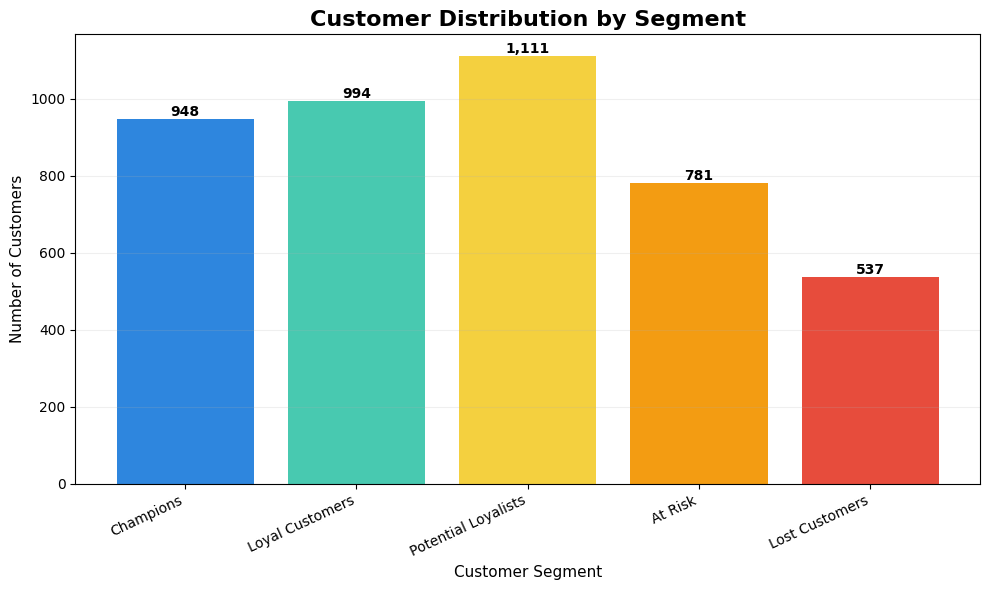

In [ ]:
import matplotlib.pyplot as plt

# Define consistent colors for our segments
segment_colors = {
    "Champions": "#2E86DE",
    "Loyal Customers": "#48C9B0",
    "Potential Loyalists": "#F4D03F",
    "At Risk": "#F39C12",
    "Lost Customers": "#E74C3C"
}

segment_counts = rfm["Segment"].value_counts()

# Reorder segments
segment_order = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "At Risk",
    "Lost Customers"
]

segment_counts = segment_counts.reindex(segment_order)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    segment_counts.index,
    segment_counts.values,
    color=[segment_colors[x] for x in segment_counts.index]
)

plt.title(
    "Customer Distribution by Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment", fontsize=11)
plt.ylabel("Number of Customers", fontsize=11)

plt.xticks(rotation=25, ha="right")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

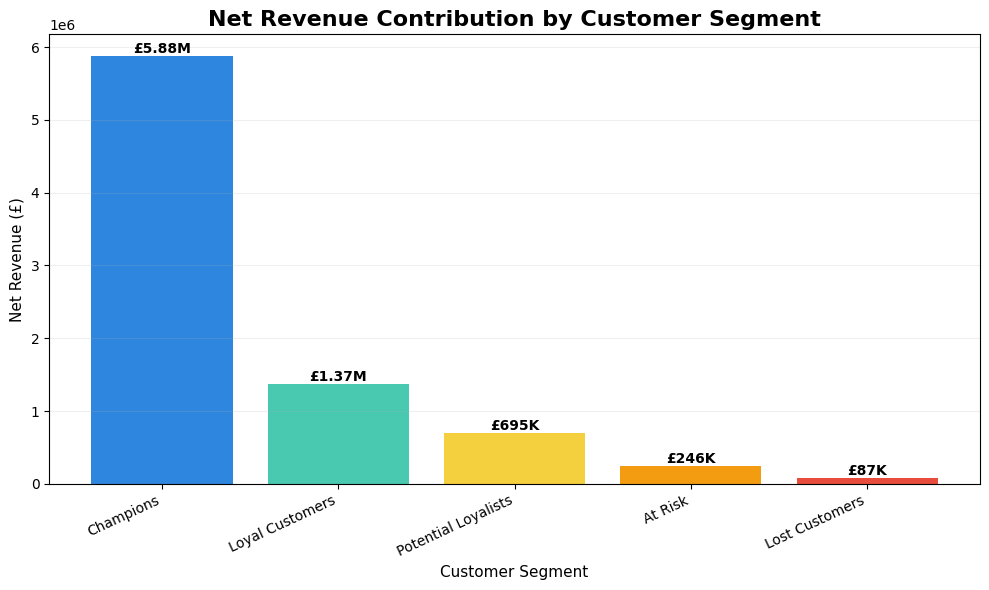

In [ ]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .reindex(segment_order)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    segment_revenue.index,
    segment_revenue.values,
    color=[segment_colors[x] for x in segment_revenue.index]
)

plt.title(
    "Net Revenue Contribution by Customer Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment", fontsize=11)
plt.ylabel("Net Revenue (£)", fontsize=11)

plt.xticks(rotation=25, ha="right")

# Add revenue labels
for bar in bars:
    height = bar.get_height()

    if height >= 1_000_000:
        label = f"£{height/1_000_000:.2f}M"
    else:
        label = f"£{height/1_000:.0f}K"

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        label,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Revenue=("Monetary", "sum")
)

segment_summary["Customer_%"] = (
    segment_summary["Customers"] /
    segment_summary["Customers"].sum() * 100
)

segment_summary["Revenue_%"] = (
    segment_summary["Revenue"] /
    segment_summary["Revenue"].sum() * 100
)

segment_summary = segment_summary.reindex(segment_order)

print(segment_summary)

                     Customers      Revenue  Customer_%  Revenue_%
Segment                                                           
Champions                  948  5880205.090   21.688401  71.029671
Loyal Customers            994  1371010.251   22.740792  16.561056
Potential Loyalists       1111   694607.972   25.417525   8.390486
At Risk                    781   246130.551   17.867765   2.973123
Lost Customers             537    86565.560   12.285518   1.045665


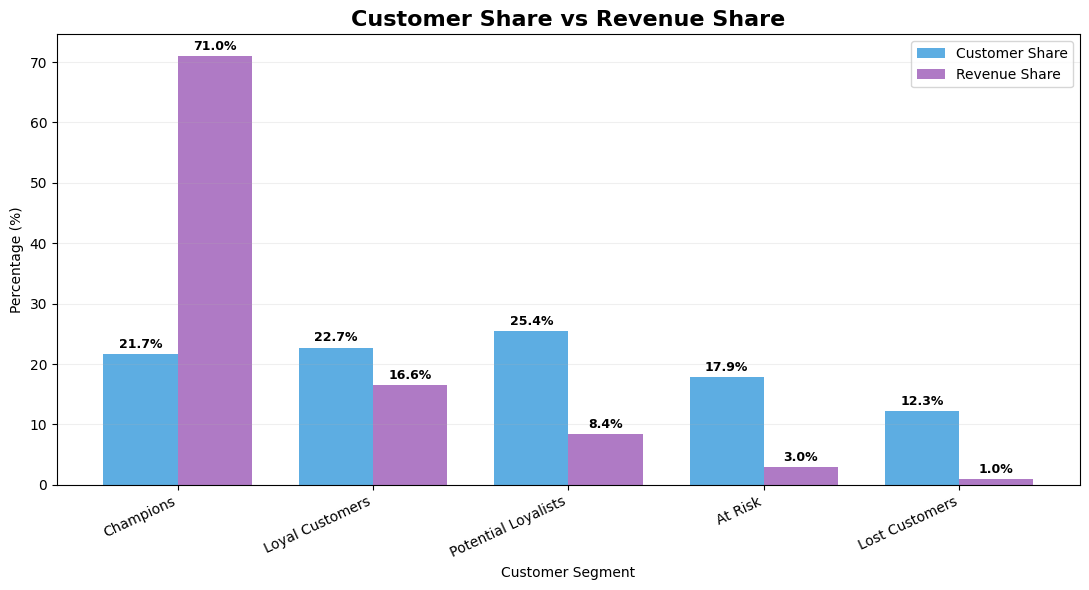

In [ ]:
plt.figure(figsize=(11, 6))

x = range(len(segment_summary))
width = 0.38

customer_bars = plt.bar(
    [i - width/2 for i in x],
    segment_summary["Customer_%"],
    width=width,
    label="Customer Share",
    color="#5DADE2"
)

revenue_bars = plt.bar(
    [i + width/2 for i in x],
    segment_summary["Revenue_%"],
    width=width,
    label="Revenue Share",
    color="#AF7AC5"
)

plt.title(
    "Customer Share vs Revenue Share",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Percentage (%)")

plt.xticks(
    x,
    segment_summary.index,
    rotation=25,
    ha="right"
)

# Add percentage labels
for bar in customer_bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

for bar in revenue_bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

In [ ]:
customer_aov = (
    df_clean.groupby("CustomerID")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
)

customer_aov["AOV"] = (
    customer_aov["Total_Revenue"] /
    customer_aov["Orders"]
)

rfm = rfm.merge(
    customer_aov[["CustomerID", "AOV"]],
    on="CustomerID",
    how="left"
)

In [ ]:
rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Avg_Order_Value=("AOV", "mean")
).reindex(segment_order)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Order_Value
Segment,,,,,
Champions,948,12.998945,14.112869,6202.747985,393.849040
Loyal Customers,994,42.870221,4.615694,1379.285967,333.079918
Potential Loyalists,1111,81.296130,2.305131,625.209696,341.189051
At Risk,781,150.402049,1.398207,315.147953,264.908943
Lost Customers,537,256.348231,1.054004,161.202160,157.631061


In [ ]:
country_analysis = df_clean.groupby("Country").agg(
    Customers=("CustomerID", "nunique"),
    Orders=("InvoiceNo", "nunique"),
    Revenue=("Revenue", "sum")
).reset_index()

country_analysis["AOV"] = (
    country_analysis["Revenue"] /
    country_analysis["Orders"]
)

country_analysis = country_analysis.sort_values(
    "Revenue",
    ascending=False
)

country_analysis.head(10)

,Country,Customers,Orders,Revenue,AOV
35,United Kingdom,3949,19854,6747156.154,339.838630
23,Netherlands,9,100,284661.540,2846.615400
10,EIRE,3,319,250001.780,783.704639
14,Germany,95,603,221509.470,367.345721
13,France,87,458,196626.050,429.314520
0,Australia,9,69,137009.770,1985.648841
32,Switzerland,21,71,55739.400,785.061972
30,Spain,31,105,54756.030,521.486000
3,Belgium,25,119,40910.960,343.789580
31,Sweden,8,46,36585.410,795.335000


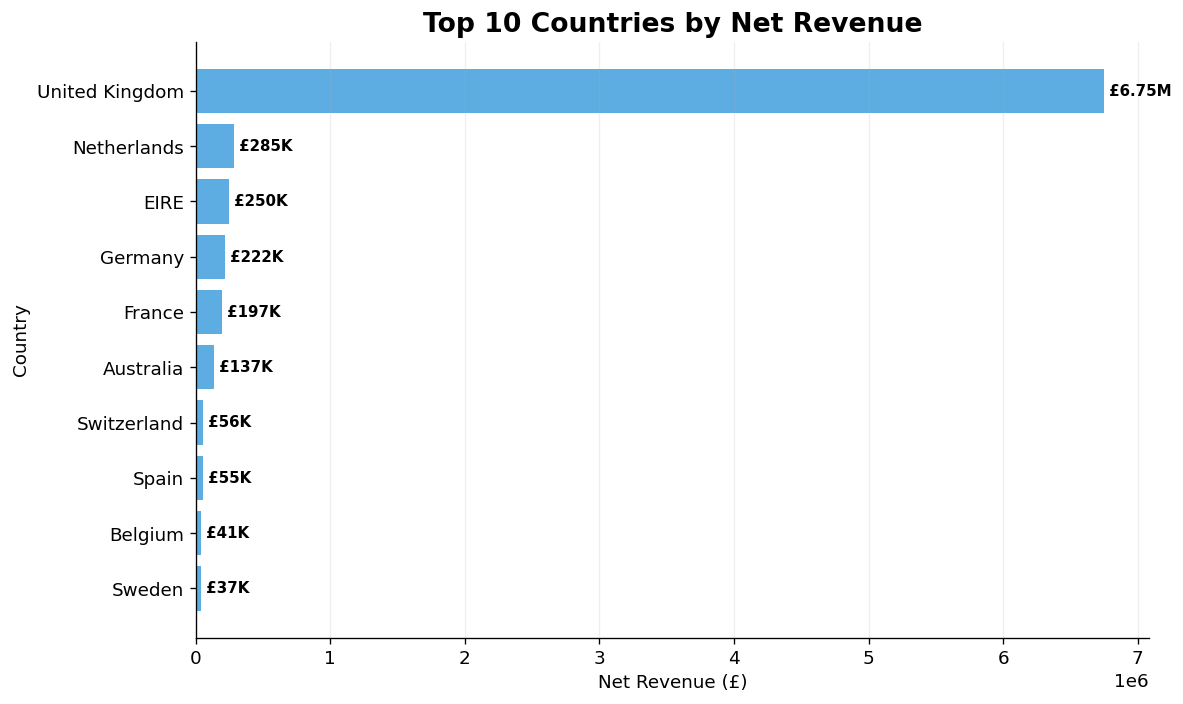

In [ ]:
top_countries = country_analysis.head(10).sort_values("Revenue")

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_countries["Country"],
    top_countries["Revenue"],
    color="#5DADE2"
)

plt.title(
    "Top 10 Countries by Net Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Net Revenue (£)")
plt.ylabel("Country")

for bar in bars:
    width = bar.get_width()

    if width >= 1_000_000:
        label = f"£{width/1_000_000:.2f}M"
    else:
        label = f"£{width/1_000:.0f}K"

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        " " + label,
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
country_analysis["Customer_%"] = (
    country_analysis["Customers"] /
    country_analysis["Customers"].sum() * 100
)

country_analysis["Revenue_%"] = (
    country_analysis["Revenue"] /
    country_analysis["Revenue"].sum() * 100
)

country_analysis.head(10)

,Country,Customers,Orders,Revenue,AOV,Customer_%,Revenue_%
35,United Kingdom,3949,19854,6747156.154,339.838630,90.180406,81.501967
23,Netherlands,9,100,284661.540,2846.615400,0.205526,3.438556
10,EIRE,3,319,250001.780,783.704639,0.068509,3.019885
14,Germany,95,603,221509.470,367.345721,2.169445,2.675714
13,France,87,458,196626.050,429.314520,1.986755,2.375135
0,Australia,9,69,137009.770,1985.648841,0.205526,1.655003
32,Switzerland,21,71,55739.400,785.061972,0.479562,0.673302
30,Spain,31,105,54756.030,521.486000,0.707924,0.661423
3,Belgium,25,119,40910.960,343.789580,0.570907,0.494182
31,Sweden,8,46,36585.410,795.335000,0.182690,0.441932


In [ ]:
country_analysis["Revenue_per_Customer"] = (
    country_analysis["Revenue"] /
    country_analysis["Customers"]
)

country_analysis.sort_values(
    "Revenue_per_Customer",
    ascending=False
).head(10)

,Country,Customers,Orders,Revenue,AOV,Customer_%,Revenue_%,Revenue_per_Customer
10,EIRE,3,319,250001.78,783.704639,0.068509,3.019885,83333.926667
23,Netherlands,9,100,284661.54,2846.615400,0.205526,3.438556,31629.060000
0,Australia,9,69,137009.77,1985.648841,0.205526,1.655003,15223.307778
29,Singapore,1,10,9120.39,912.039000,0.022836,0.110169,9120.390000
31,Sweden,8,46,36585.41,795.335000,0.182690,0.441932,4573.176250
19,Japan,8,28,35340.62,1262.165000,0.182690,0.426895,4417.577500
16,Iceland,1,7,4310.00,615.714286,0.022836,0.052062,4310.000000
24,Norway,10,40,35163.46,879.086500,0.228363,0.424755,3516.346000
32,Switzerland,21,71,55739.40,785.061972,0.479562,0.673302,2654.257143
14,Germany,95,603,221509.47,367.345721,2.169445,2.675714,2331.678632


In [ ]:
df_segmented = df_clean.merge(
    rfm[["CustomerID", "Segment"]],
    on="CustomerID",
    how="left"
)
champion_country = (
    df_segmented[df_segmented["Segment"] == "Champions"]
    .groupby("Country")
    .agg(
        Champions=("CustomerID", "nunique"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

champion_country.head(10)

,Country,Champions,Revenue
22,United Kingdom,837,4657578.63
14,Netherlands,1,279489.02
6,EIRE,2,245673.32
9,Germany,30,162026.71
8,France,30,161743.63
0,Australia,3,131882.22
19,Spain,8,39814.73
20,Sweden,2,32627.95
12,Japan,2,28001.05
2,Belgium,9,24959.72


In [ ]:
top_customers = (
    rfm.sort_values("Monetary", ascending=False)
    [["CustomerID", "Segment", "Recency", "Frequency", "Monetary", "AOV"]]
    .head(10)
)

top_customers

,CustomerID,Segment,Recency,Frequency,Monetary,AOV
1702,14646.0,Champions,1,76,279489.02,3677.487105
4232,18102.0,Champions,0,62,256438.49,4136.104677
3757,17450.0,Champions,8,55,187322.17,3405.857636
1894,14911.0,Champions,1,248,132458.73,534.107782
55,12415.0,Champions,24,26,123725.45,4758.671154
1344,14156.0,Champions,9,66,113214.59,1715.372576
3800,17511.0,Champions,2,46,88125.38,1915.769130
3201,16684.0,Champions,4,31,65892.08,2125.550968
1004,13694.0,Champions,3,60,62690.54,1044.842333
2191,15311.0,Champions,0,118,59284.19,502.408390


In [ ]:
df_segmented[df_segmented["CustomerID"].isin(
    top_customers["CustomerID"]
)][
    ["CustomerID", "Country", "InvoiceNo", "Description",
     "Quantity", "UnitPrice", "Revenue"]
].sort_values(
    "Revenue",
    ascending=False
).head(20)

,CustomerID,Country,InvoiceNo,Description,Quantity,UnitPrice,Revenue
251979,17450.0,United Kingdom,567423,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72
312007,14646.0,Netherlands,573003,RABBIT NIGHT LIGHT,2400,2.08,4992.00
32534,17450.0,United Kingdom,540689,HEART OF WICKER LARGE,1284,3.21,4121.64
10677,18102.0,United Kingdom,537659,VINTAGE UNION JACK MEMOBOARD,600,6.38,3828.00
251973,17450.0,United Kingdom,567423,PANTRY CHOPPING BOARD,756,5.06,3825.36
251977,17450.0,United Kingdom,567423,SET OF 6 SPICE TINS PANTRY DESIGN,852,4.25,3621.00
303397,18102.0,United Kingdom,572209,LANDMARK FRAME COVENT GARDEN,300,10.95,3285.00
303403,18102.0,United Kingdom,572209,LANDMARK FRAME BAKER STREET,300,10.95,3285.00
303399,18102.0,United Kingdom,572209,LANDMARK FRAME NOTTING HILL,300,10.95,3285.00
303400,18102.0,United Kingdom,572209,LANDMARK FRAME LONDON BRIDGE,300,10.95,3285.00


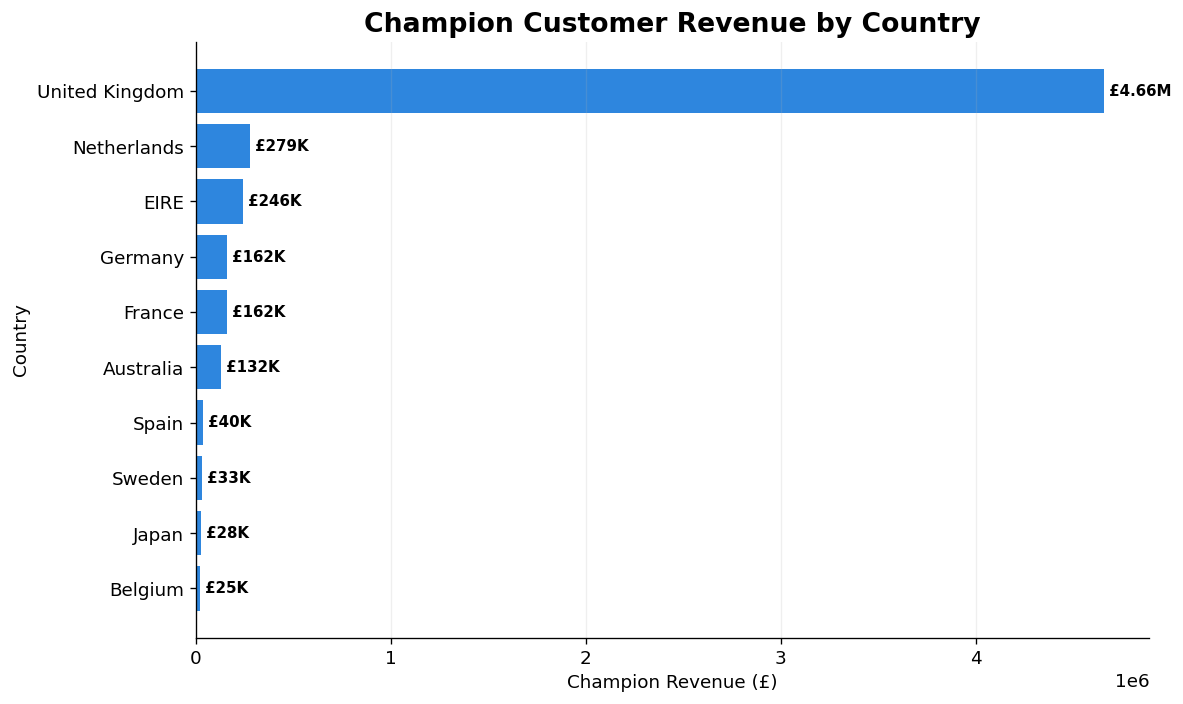

In [ ]:
champion_plot = champion_country.head(10).sort_values("Revenue")

plt.figure(figsize=(10, 6))

bars = plt.barh(
    champion_plot["Country"],
    champion_plot["Revenue"],
    color="#2E86DE"
)

plt.title(
    "Champion Customer Revenue by Country",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Champion Revenue (£)")
plt.ylabel("Country")

for bar in bars:
    width = bar.get_width()

    if width >= 1_000_000:
        label = f"£{width/1_000_000:.2f}M"
    else:
        label = f"£{width/1_000:.0f}K"

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        " " + label,
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
top_customer_ids = top_customers["CustomerID"].tolist()

top_transactions = df_segmented[
    df_segmented["CustomerID"].isin(top_customer_ids)
][
    [
        "CustomerID",
        "Country",
        "InvoiceNo",
        "Description",
        "Quantity",
        "UnitPrice",
        "Revenue"
    ]
].sort_values("Revenue", ascending=False)

top_transactions.head(20)

,CustomerID,Country,InvoiceNo,Description,Quantity,UnitPrice,Revenue
251979,17450.0,United Kingdom,567423,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72
312007,14646.0,Netherlands,573003,RABBIT NIGHT LIGHT,2400,2.08,4992.00
32534,17450.0,United Kingdom,540689,HEART OF WICKER LARGE,1284,3.21,4121.64
10677,18102.0,United Kingdom,537659,VINTAGE UNION JACK MEMOBOARD,600,6.38,3828.00
251973,17450.0,United Kingdom,567423,PANTRY CHOPPING BOARD,756,5.06,3825.36
251977,17450.0,United Kingdom,567423,SET OF 6 SPICE TINS PANTRY DESIGN,852,4.25,3621.00
303397,18102.0,United Kingdom,572209,LANDMARK FRAME COVENT GARDEN,300,10.95,3285.00
303403,18102.0,United Kingdom,572209,LANDMARK FRAME BAKER STREET,300,10.95,3285.00
303399,18102.0,United Kingdom,572209,LANDMARK FRAME NOTTING HILL,300,10.95,3285.00
303400,18102.0,United Kingdom,572209,LANDMARK FRAME LONDON BRIDGE,300,10.95,3285.00


In [ ]:
champion_country["Revenue_per_Champion"] = (
    champion_country["Revenue"] /
    champion_country["Champions"]
)

champion_country.head(10)

,Country,Champions,Revenue,Revenue_per_Champion
22,United Kingdom,837,4657578.63,5564.610072
14,Netherlands,1,279489.02,279489.020000
6,EIRE,2,245673.32,122836.660000
9,Germany,30,162026.71,5400.890333
8,France,30,161743.63,5391.454333
0,Australia,3,131882.22,43960.740000
19,Spain,8,39814.73,4976.841250
20,Sweden,2,32627.95,16313.975000
12,Japan,2,28001.05,14000.525000
2,Belgium,9,24959.72,2773.302222


In [ ]:
champion_country.sort_values(
    "Revenue_per_Champion",
    ascending=False
).head(10)

,Country,Champions,Revenue,Revenue_per_Champion
14,Netherlands,1,279489.02,279489.020000
6,EIRE,2,245673.32,122836.660000
0,Australia,3,131882.22,43960.740000
20,Sweden,2,32627.95,16313.975000
12,Japan,2,28001.05,14000.525000
18,Singapore,1,9120.39,9120.390000
15,Norway,3,20185.29,6728.430000
4,Cyprus,1,6182.98,6182.980000
21,Switzerland,3,16704.15,5568.050000
22,United Kingdom,837,4657578.63,5564.610072


In [ ]:
champion_country["Revenue_per_Champion"] = (
    champion_country["Revenue"] /
    champion_country["Champions"]
)

champion_country.sort_values(
    "Revenue_per_Champion",
    ascending=False
).head(10)

,Country,Champions,Revenue,Revenue_per_Champion
14,Netherlands,1,279489.02,279489.020000
6,EIRE,2,245673.32,122836.660000
0,Australia,3,131882.22,43960.740000
20,Sweden,2,32627.95,16313.975000
12,Japan,2,28001.05,14000.525000
18,Singapore,1,9120.39,9120.390000
15,Norway,3,20185.29,6728.430000
4,Cyprus,1,6182.98,6182.980000
21,Switzerland,3,16704.15,5568.050000
22,United Kingdom,837,4657578.63,5564.610072


In [ ]:
uk_champion_revenue = champion_country.loc[
    champion_country["Country"] == "United Kingdom",
    "Revenue"
].iloc[0]

total_champion_revenue = champion_country["Revenue"].sum()

uk_champion_share = (
    uk_champion_revenue /
    total_champion_revenue * 100
)

print(f"UK Champion Revenue Share: {uk_champion_share:.2f}%")

UK Champion Revenue Share: 79.21%


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Select RFM variables
rfm_ml = rfm[
    ["CustomerID", "Recency", "Frequency", "Monetary"]
].copy()

# Log transform to reduce the effect of extreme values
rfm_ml["Recency_Log"] = np.log1p(rfm_ml["Recency"])
rfm_ml["Frequency_Log"] = np.log1p(rfm_ml["Frequency"])
rfm_ml["Monetary_Log"] = np.log1p(rfm_ml["Monetary"])

# Features for machine learning
features = [
    "Recency_Log",
    "Frequency_Log",
    "Monetary_Log"
]

# Standardize
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_ml[features]
)

print("Original RFM shape:", rfm_ml[features].shape)
print("Scaled RFM shape:", rfm_scaled.shape)

Original RFM shape: (4371, 3)
Scaled RFM shape: (4371, 3)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
print("NaN values:")
print(rfm_ml[["Recency", "Frequency", "Monetary"]].isnull().sum())

print("\nMonetary minimum:", rfm_ml["Monetary"].min())
print("Monetary values <= 0:", (rfm_ml["Monetary"] <= 0).sum())

NaN values:
Recency      0
Frequency    0
Monetary     0
dtype: int64

Monetary minimum: -4287.63
Monetary values <= 0: 49


In [ ]:
rfm_ml = rfm[
    (rfm["Monetary"] > 0) &
    (rfm["Frequency"] > 0)
][
    ["CustomerID", "Recency", "Frequency", "Monetary"]
].copy()

print("Customers available for ML:", len(rfm_ml))

Customers available for ML: 4322


In [ ]:
rfm_ml["Recency_Log"] = np.log1p(rfm_ml["Recency"])
rfm_ml["Frequency_Log"] = np.log1p(rfm_ml["Frequency"])
rfm_ml["Monetary_Log"] = np.log1p(rfm_ml["Monetary"])

features = [
    "Recency_Log",
    "Frequency_Log",
    "Monetary_Log"
]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_ml[features]
)

print("Scaled data shape:", rfm_scaled.shape)
print("Missing values:", np.isnan(rfm_scaled).sum())

Scaled data shape: (4322, 3)
Missing values: 0


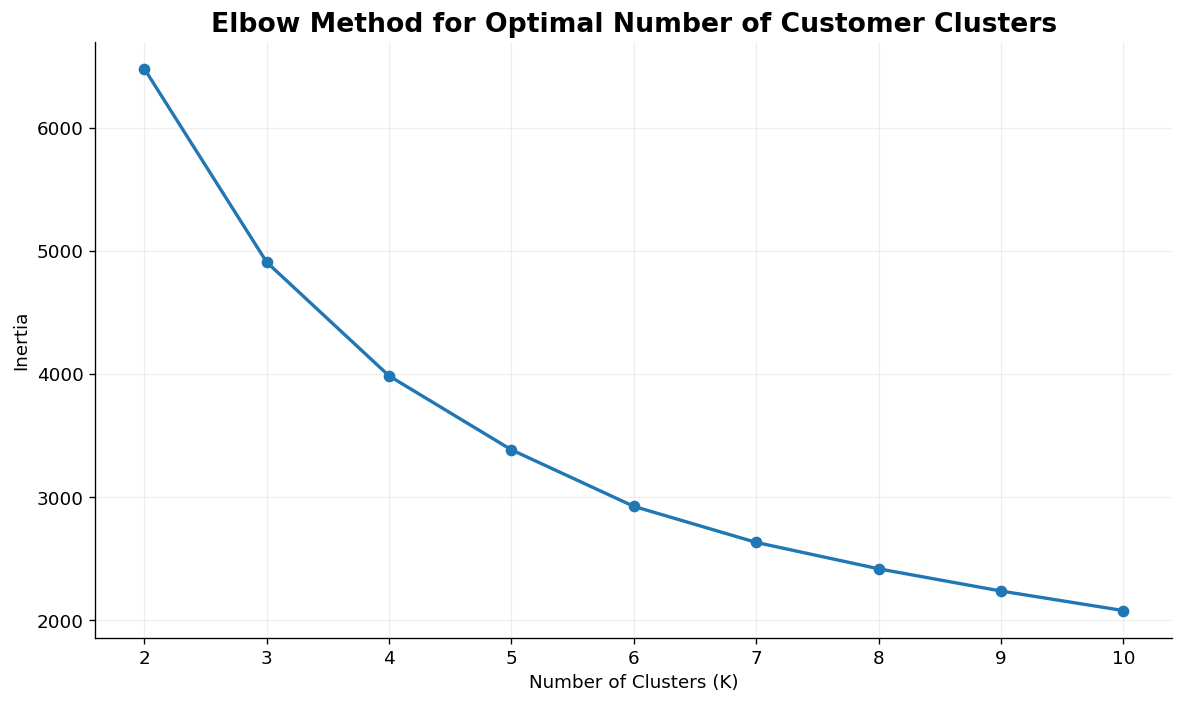

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    inertia,
    marker="o",
    linewidth=2
)

plt.title(
    "Elbow Method for Optimal Number of Customer Clusters",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(K_range)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans

# Final K-Means model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Fit model and assign clusters
rfm_ml["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed!")
print("\nCustomers per cluster:")
print(rfm_ml["Cluster"].value_counts().sort_index())

K-Means clustering completed!

Customers per cluster:
Cluster
0    1178
1    1047
2     956
3     444
4     697
Name: count, dtype: int64


In [ ]:
cluster_profile = (
    rfm_ml
    .groupby("Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .round(2)
)

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,1178,217.98,1.45,310.30
1,1047,81.87,4.80,1605.74
2,956,35.70,1.65,375.19
3,444,12.26,22.05,10716.01
4,697,9.14,5.75,1618.96


In [ ]:
cluster_revenue = (
    rfm_ml
    .groupby("Cluster")["Monetary"]
    .sum()
    .round(2)
)

cluster_profile["Total_Revenue"] = cluster_revenue

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Cluster,,,,,
0,1178,217.98,1.45,310.30,365529.13
1,1047,81.87,4.80,1605.74,1681212.48
2,956,35.70,1.65,375.19,358684.62
3,444,12.26,22.05,10716.01,4757909.89
4,697,9.14,5.75,1618.96,1128412.44


In [ ]:
cluster_profile = (
    rfm_ml
    .groupby("Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
    .round(2)
)

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Cluster,,,,,
0,1178,217.98,1.45,310.30,365529.13
1,1047,81.87,4.80,1605.74,1681212.48
2,956,35.70,1.65,375.19,358684.62
3,444,12.26,22.05,10716.01,4757909.89
4,697,9.14,5.75,1618.96,1128412.44


In [ ]:
cluster_profile["Customer_Share_%"] = (
    cluster_profile["Customers"] /
    cluster_profile["Customers"].sum() * 100
)

cluster_profile["Revenue_Share_%"] = (
    cluster_profile["Total_Revenue"] /
    cluster_profile["Total_Revenue"].sum() * 100
)

cluster_profile.round(2)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Share_%,Revenue_Share_%
Cluster,,,,,,,
0,1178,217.98,1.45,310.30,365529.13,27.26,4.41
1,1047,81.87,4.80,1605.74,1681212.48,24.22,20.28
2,956,35.70,1.65,375.19,358684.62,22.12,4.33
3,444,12.26,22.05,10716.01,4757909.89,10.27,57.38
4,697,9.14,5.75,1618.96,1128412.44,16.13,13.61


In [ ]:
cluster_profile["Customer_Share_%"] = (
    cluster_profile["Customers"] /
    cluster_profile["Customers"].sum() * 100
)

cluster_profile["Revenue_Share_%"] = (
    cluster_profile["Total_Revenue"] /
    cluster_profile["Total_Revenue"].sum() * 100
)

cluster_profile.round(2)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Share_%,Revenue_Share_%
Cluster,,,,,,,
0,1178,217.98,1.45,310.30,365529.13,27.26,4.41
1,1047,81.87,4.80,1605.74,1681212.48,24.22,20.28
2,956,35.70,1.65,375.19,358684.62,22.12,4.33
3,444,12.26,22.05,10716.01,4757909.89,10.27,57.38
4,697,9.14,5.75,1618.96,1128412.44,16.13,13.61


In [ ]:
cluster_summary = cluster_profile[
    [
        "Customers",
        "Customer_Share_%",
        "Avg_Recency",
        "Avg_Frequency",
        "Avg_Monetary",
        "Total_Revenue",
        "Revenue_Share_%"
    ]
].round(2)

cluster_summary

,Customers,Customer_Share_%,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share_%
Cluster,,,,,,,
0,1178,27.26,217.98,1.45,310.30,365529.13,4.41
1,1047,24.22,81.87,4.80,1605.74,1681212.48,20.28
2,956,22.12,35.70,1.65,375.19,358684.62,4.33
3,444,10.27,12.26,22.05,10716.01,4757909.89,57.38
4,697,16.13,9.14,5.75,1618.96,1128412.44,13.61


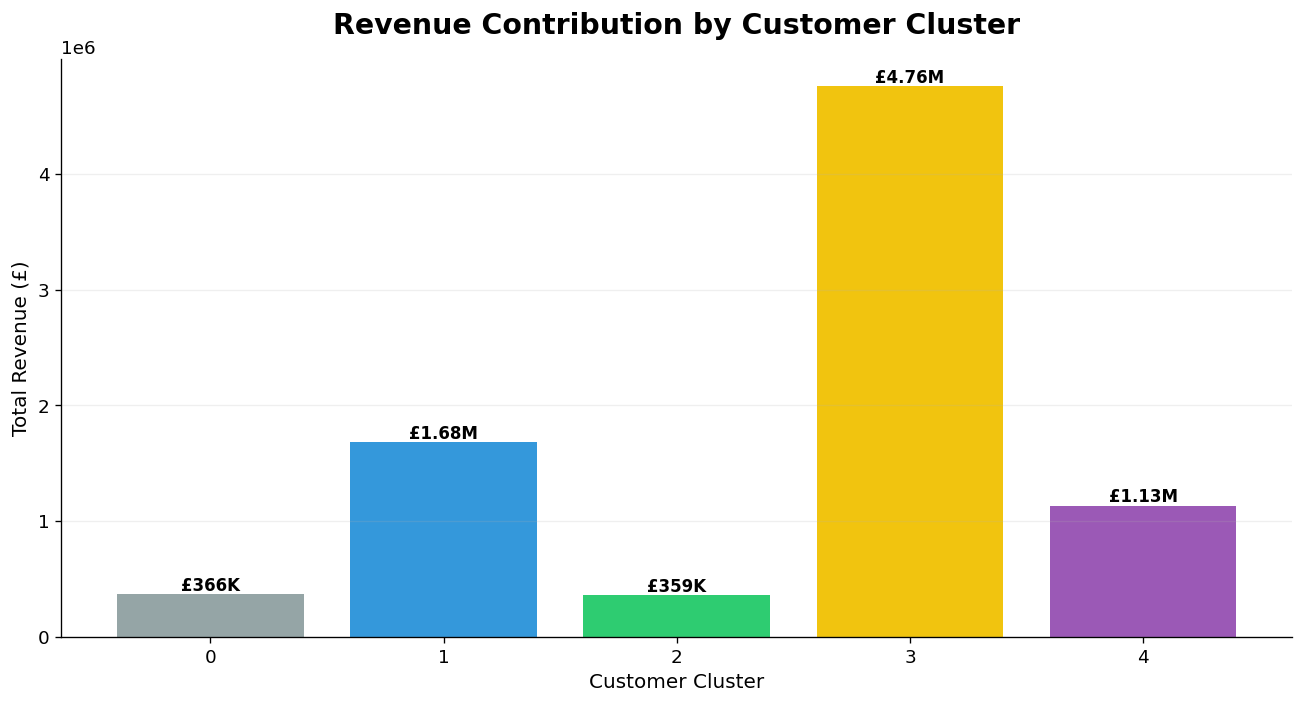

In [ ]:
plt.figure(figsize=(11, 6))

bars = plt.bar(
    cluster_profile.index.astype(str),
    cluster_profile["Total_Revenue"],
    color=[
        "#95A5A6",
        "#3498DB",
        "#2ECC71",
        "#F1C40F",
        "#9B59B6"
    ]
)

plt.title(
    "Revenue Contribution by Customer Cluster",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Customer Cluster", fontsize=12)
plt.ylabel("Total Revenue (£)", fontsize=12)

plt.grid(
    axis="y",
    alpha=0.2
)

for bar in bars:

    height = bar.get_height()

    if height >= 1_000_000:
        label = f"£{height/1_000_000:.2f}M"
    else:
        label = f"£{height/1_000:.0f}K"

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        label,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

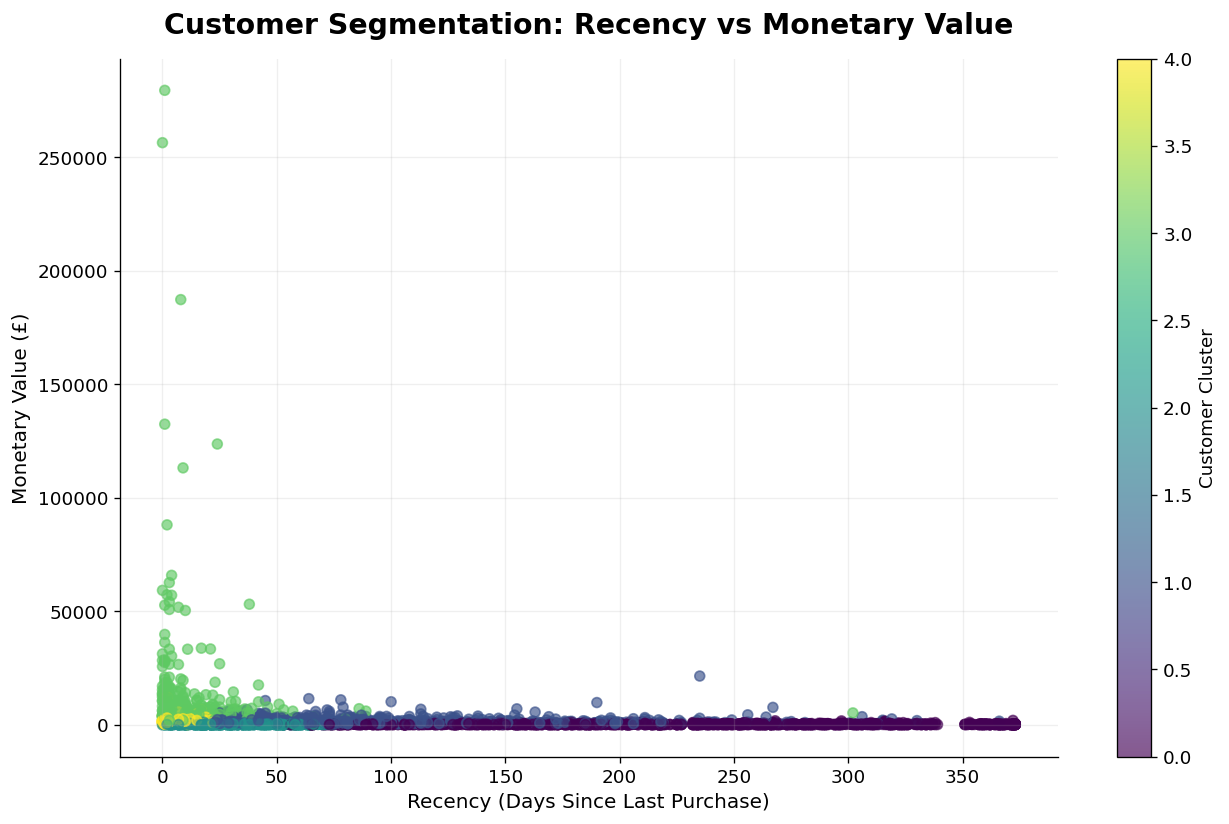

In [ ]:
plt.figure(figsize=(11, 7))

scatter = plt.scatter(
    rfm_ml["Recency"],
    rfm_ml["Monetary"],
    c=rfm_ml["Cluster"],
    cmap="viridis",
    s=35,
    alpha=0.65
)

plt.title(
    "Customer Segmentation: Recency vs Monetary Value",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Recency (Days Since Last Purchase)",
    fontsize=12
)

plt.ylabel(
    "Monetary Value (£)",
    fontsize=12
)

plt.colorbar(
    scatter,
    label="Customer Cluster"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# Create Year-Month column
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)

monthly_sales = (
    df_clean.groupby("YearMonth")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
)

monthly_sales

,YearMonth,Revenue,Orders,Customers
0,2010-12,552372.860,1708,948
1,2011-01,473731.900,1236,783
2,2011-02,435534.070,1201,798
3,2011-03,578576.210,1619,1020
4,2011-04,425222.671,1384,899
5,2011-05,647011.670,1849,1079
6,2011-06,606862.520,1707,1051
7,2011-07,573112.321,1593,993
8,2011-08,615078.090,1543,980
9,2011-09,929356.232,2077,1302


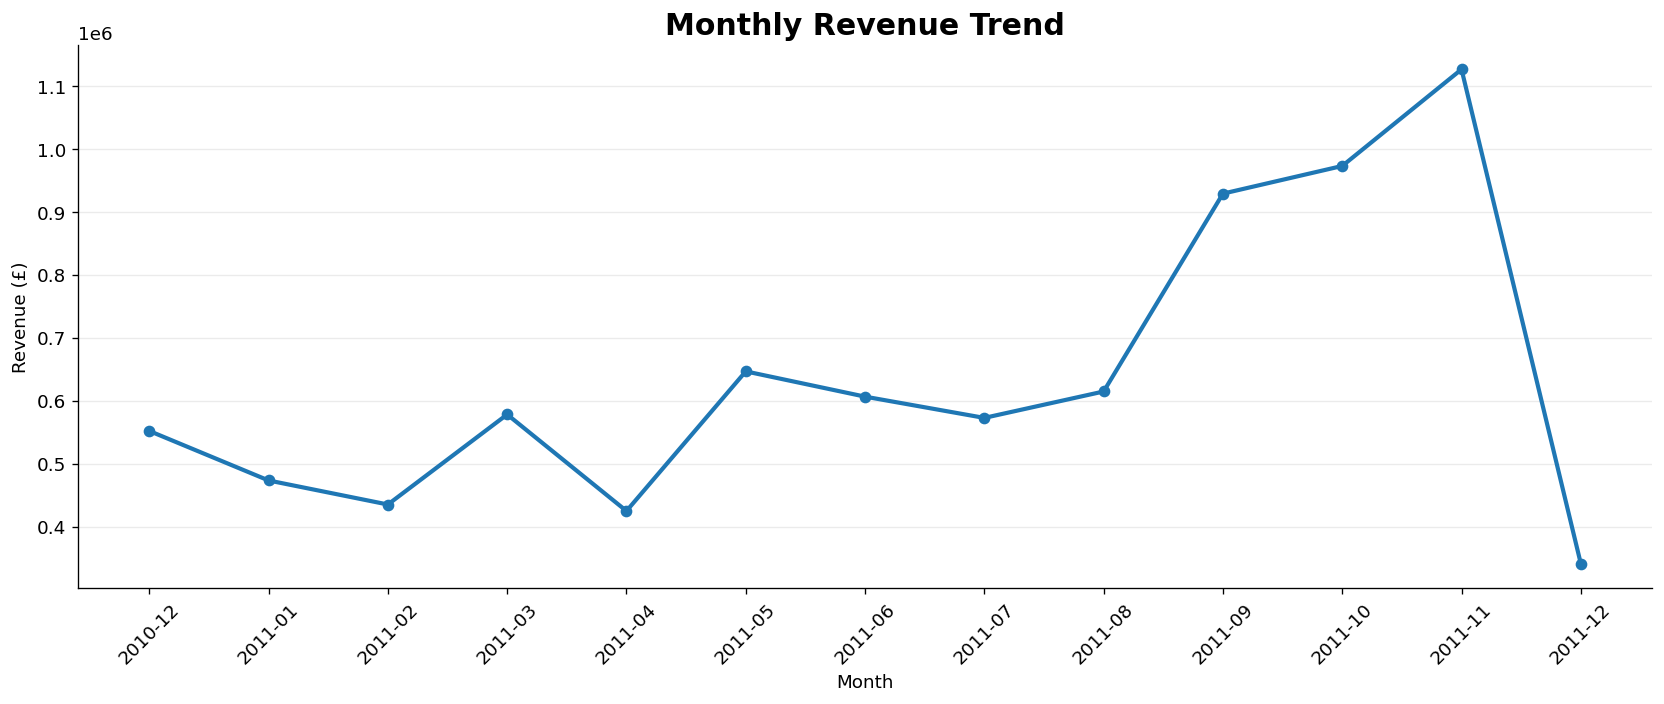

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["Revenue"],
    marker="o",
    linewidth=2.5
)

plt.title("Monthly Revenue Trend", fontsize=18, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
top_products = (
    df_clean.groupby(["StockCode", "Description"])
    .agg(
        Quantity=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

top_products.head(10)

,StockCode,Description,Quantity,Revenue
1249,22423,REGENCY CAKESTAND 3 TIER,11519,132567.70
3593,85123A,WHITE HANGING HEART T-LIGHT HOLDER,34128,93767.80
3586,85099B,JUMBO BAG RED RETROSPOT,44963,83056.52
2613,47566,PARTY BUNTING,15011,67628.43
3915,POST,POSTAGE,3002,66710.24
2818,84879,ASSORTED COLOUR BIRD ORNAMENT,35215,56331.91
1937,23084,RABBIT NIGHT LIGHT,27045,51042.84
2680,79321,CHILLI LIGHTS,9566,45915.41
932,22086,PAPER CHAIN KIT 50'S CHRISTMAS,15138,41423.78
1324,22502,PICNIC BASKET WICKER 60 PIECES,61,39619.50


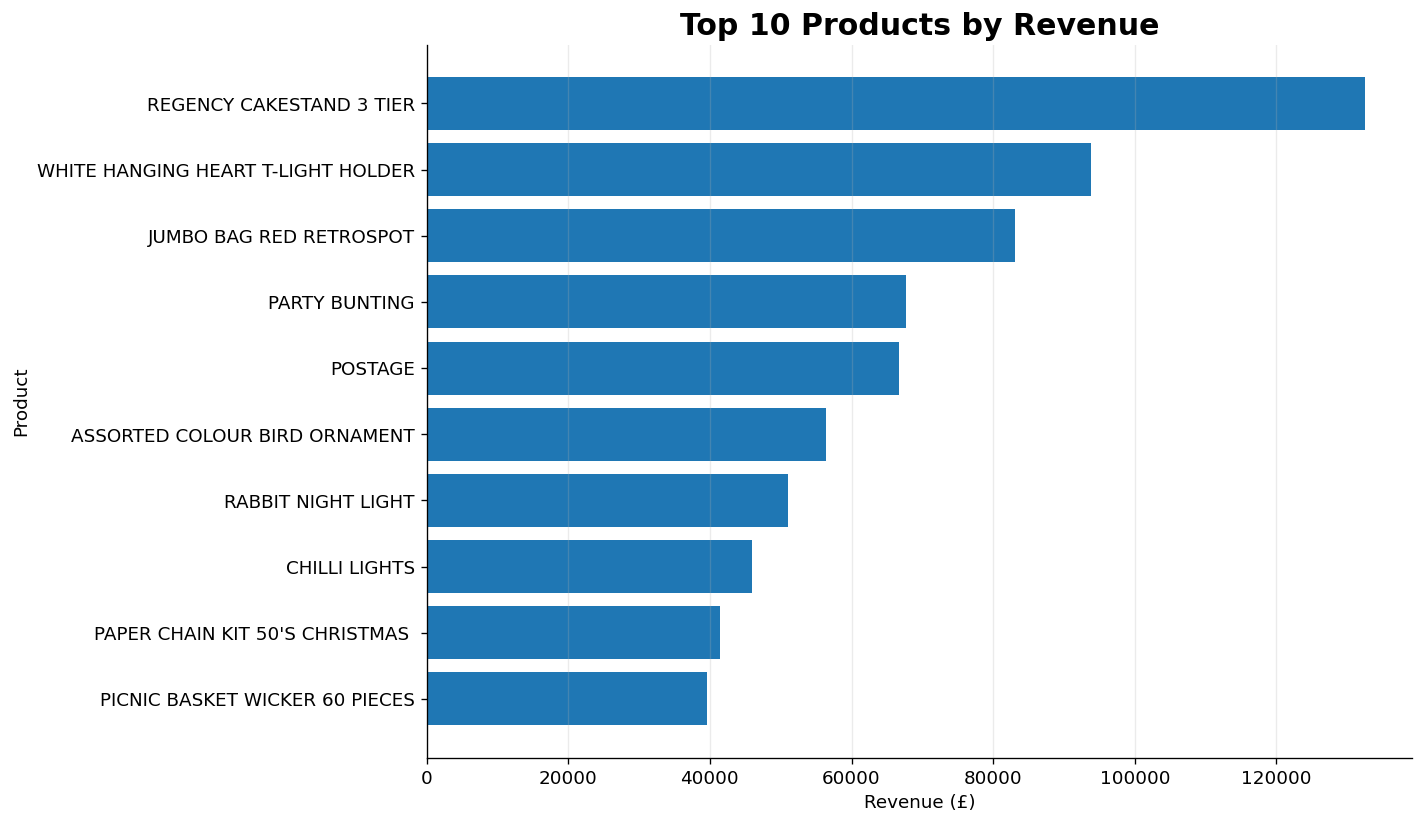

In [ ]:
top10 = top_products.head(10).sort_values("Revenue")

plt.figure(figsize=(12, 7))

plt.barh(
    top10["Description"],
    top10["Revenue"]
)

plt.title(
    "Top 10 Products by Revenue",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
country_sales = (
    df_clean.groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Customers=("CustomerID", "nunique"),
        Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

country_sales.head(15)

,Country,Revenue,Customers,Orders
35,United Kingdom,6747156.154,3949,19854
23,Netherlands,284661.540,9,100
10,EIRE,250001.780,3,319
14,Germany,221509.470,95,603
13,France,196626.050,87,458
0,Australia,137009.770,9,69
32,Switzerland,55739.400,21,71
30,Spain,54756.030,31,105
3,Belgium,40910.960,25,119
31,Sweden,36585.410,8,46


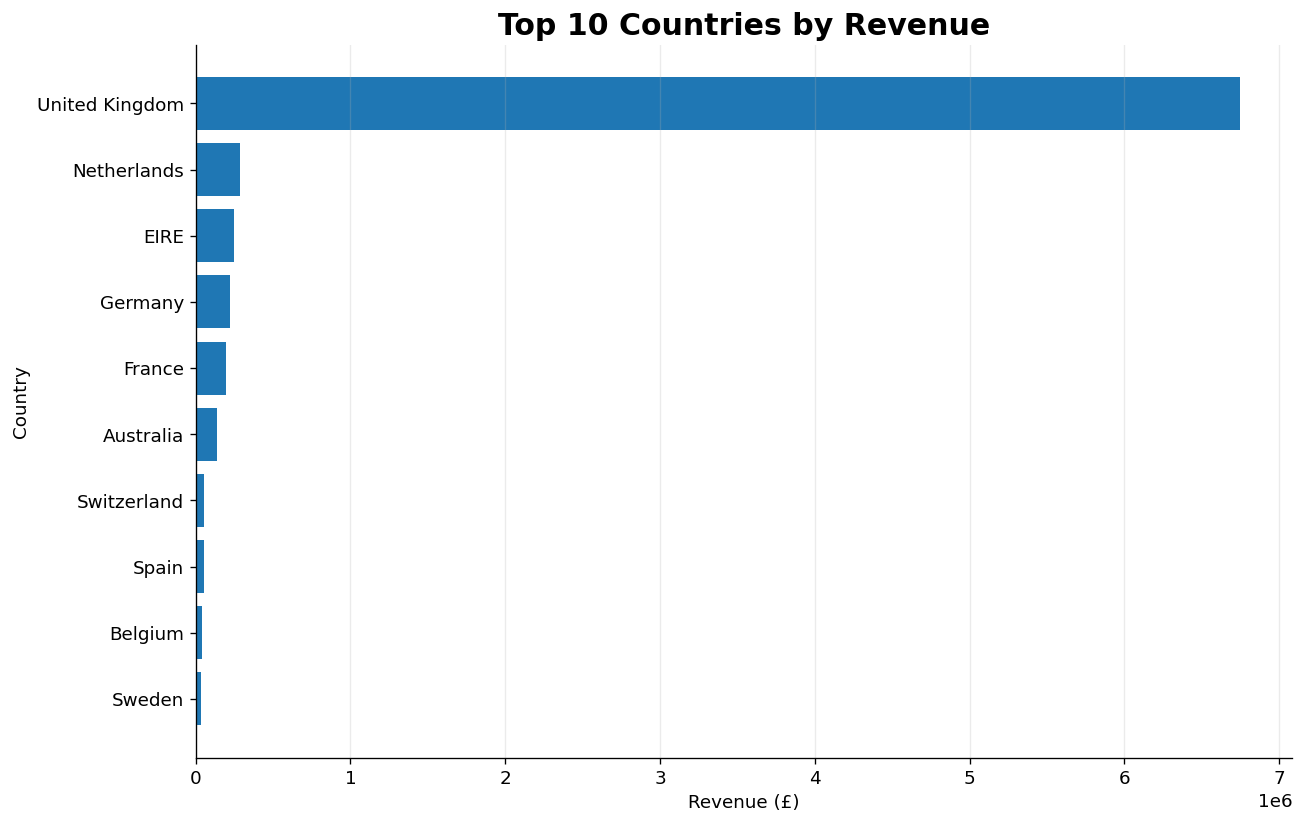

In [ ]:
top_countries = country_sales.head(10).sort_values("Revenue")

plt.figure(figsize=(11, 7))

plt.barh(
    top_countries["Country"],
    top_countries["Revenue"]
)

plt.title(
    "Top 10 Countries by Revenue",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
product_performance = (
    df_clean.groupby("Description")
    .agg(
        Quantity=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

product_performance = product_performance[
    product_performance["Quantity"] > 0
]

product_performance.head()

,Description,Quantity,Revenue
0,4 PURPLE FLOCK DINNER CANDLES,138,265.66
1,50'S CHRISTMAS GIFT BAG LARGE,1883,2269.75
2,DOLLY GIRL BEAKER,2387,2745.75
3,I LOVE LONDON MINI BACKPACK,359,1449.85
4,I LOVE LONDON MINI RUCKSACK,1,4.15


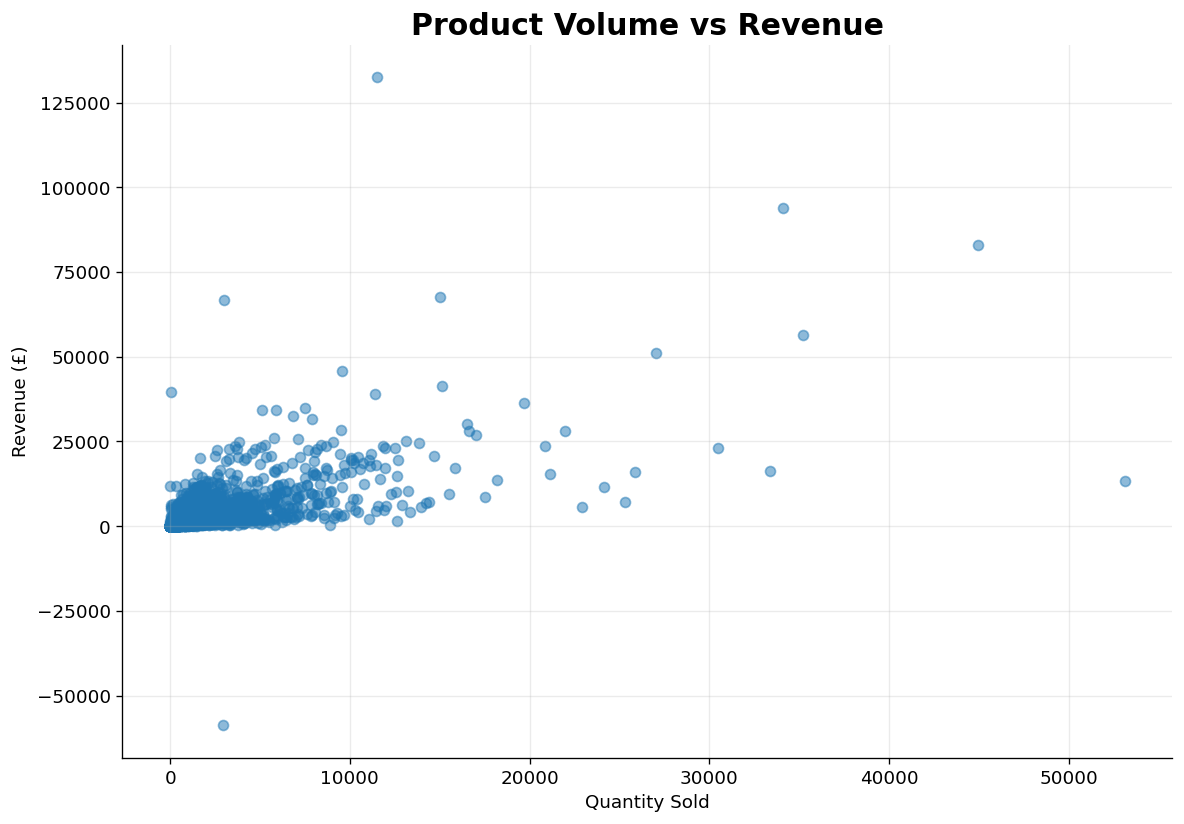

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    product_performance["Quantity"],
    product_performance["Revenue"],
    alpha=0.5
)

plt.title(
    "Product Volume vs Revenue",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Quantity Sold")
plt.ylabel("Revenue (£)")

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
returns = df_clean[df_clean["Quantity"] < 0].copy()

print("Return rows:", len(returns))
print("Return revenue:", returns["Revenue"].sum())
print("Returned quantity:", returns["Quantity"].sum())

Return rows: 8872
Return revenue: -608689.47
Returned quantity: -273035


In [ ]:
return_country = (
    returns.groupby("Country")
    .agg(
        Returned_Quantity=("Quantity", "sum"),
        Return_Value=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Return_Value")
)

return_country.head(10)

,Country,Returned_Quantity,Return_Value
27,United Kingdom,-259167,-537868.49
7,EIRE,-4196,-15260.68
10,France,-1623,-12308.26
22,Singapore,-7,-12158.90
11,Germany,-1815,-7168.93
23,Spain,-1127,-6802.53
20,Portugal,-78,-4380.08
15,Japan,-798,-2075.75
26,USA,-1424,-1849.47
24,Sweden,-446,-1782.42


In [ ]:
total_revenue = df_clean["Revenue"].sum()

gross_sales = df_clean.loc[
    df_clean["Revenue"] > 0, "Revenue"
].sum()

returns_value = df_clean.loc[
    df_clean["Revenue"] < 0, "Revenue"
].sum()

return_rate = abs(returns_value) / gross_sales * 100

print("========== BUSINESS KPI SUMMARY ==========")
print(f"Net Revenue: £{total_revenue:,.2f}")
print(f"Gross Sales: £{gross_sales:,.2f}")
print(f"Returns: £{abs(returns_value):,.2f}")
print(f"Return Rate by Value: {return_rate:.2f}%")
print(f"Customers: {df_clean['CustomerID'].nunique():,}")
print(f"Orders: {df_clean['InvoiceNo'].nunique():,}")
print(f"Products: {df_clean['StockCode'].nunique():,}")
print(f"Countries: {df_clean['Country'].nunique():,}")

========== BUSINESS KPI SUMMARY ==========
Net Revenue: £8,278,519.42
Gross Sales: £8,887,208.89
Returns: £608,689.47
Return Rate by Value: 6.85%
Customers: 4,371
Orders: 22,186
Products: 3,684
Countries: 37


In [ ]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Customer_Share=("CustomerID", lambda x: len(x) / len(rfm) * 100),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum")
).reset_index()

segment_summary["Revenue_Share"] = (
    segment_summary["Total_Revenue"] /
    segment_summary["Total_Revenue"].sum() * 100
)

segment_summary = segment_summary.sort_values(
    "Revenue_Share",
    ascending=False
)

segment_summary

,Segment,Customers,Customer_Share,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share
1,Champions,948,21.688401,12.998945,14.112869,6202.747985,5880205.090,71.029671
3,Loyal Customers,994,22.740792,42.870221,4.615694,1379.285967,1371010.251,16.561056
4,Potential Loyalists,1111,25.417525,81.296130,2.305131,625.209696,694607.972,8.390486
0,At Risk,781,17.867765,150.402049,1.398207,315.147953,246130.551,2.973123
2,Lost Customers,537,12.285518,256.348231,1.054004,161.202160,86565.560,1.045665


In [ ]:
segment_labels = {
    0: "At Risk / Lost",
    1: "Loyal Customers",
    2: "Potential Loyalists",
    3: "Champions / VIP",
    4: "Recent Customers"
}

segment_summary["Business_Segment"] = (
    segment_summary["Segment"].map(segment_labels)
)

segment_summary[
    [
        "Segment",
        "Business_Segment",
        "Customers",
        "Customer_Share",
        "Avg_Recency",
        "Avg_Frequency",
        "Avg_Monetary",
        "Total_Revenue",
        "Revenue_Share"
    ]
]

,Segment,Business_Segment,Customers,Customer_Share,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share
1,Champions,NaN,948,21.688401,12.998945,14.112869,6202.747985,5880205.090,71.029671
3,Loyal Customers,NaN,994,22.740792,42.870221,4.615694,1379.285967,1371010.251,16.561056
4,Potential Loyalists,NaN,1111,25.417525,81.296130,2.305131,625.209696,694607.972,8.390486
0,At Risk,NaN,781,17.867765,150.402049,1.398207,315.147953,246130.551,2.973123
2,Lost Customers,NaN,537,12.285518,256.348231,1.054004,161.202160,86565.560,1.045665


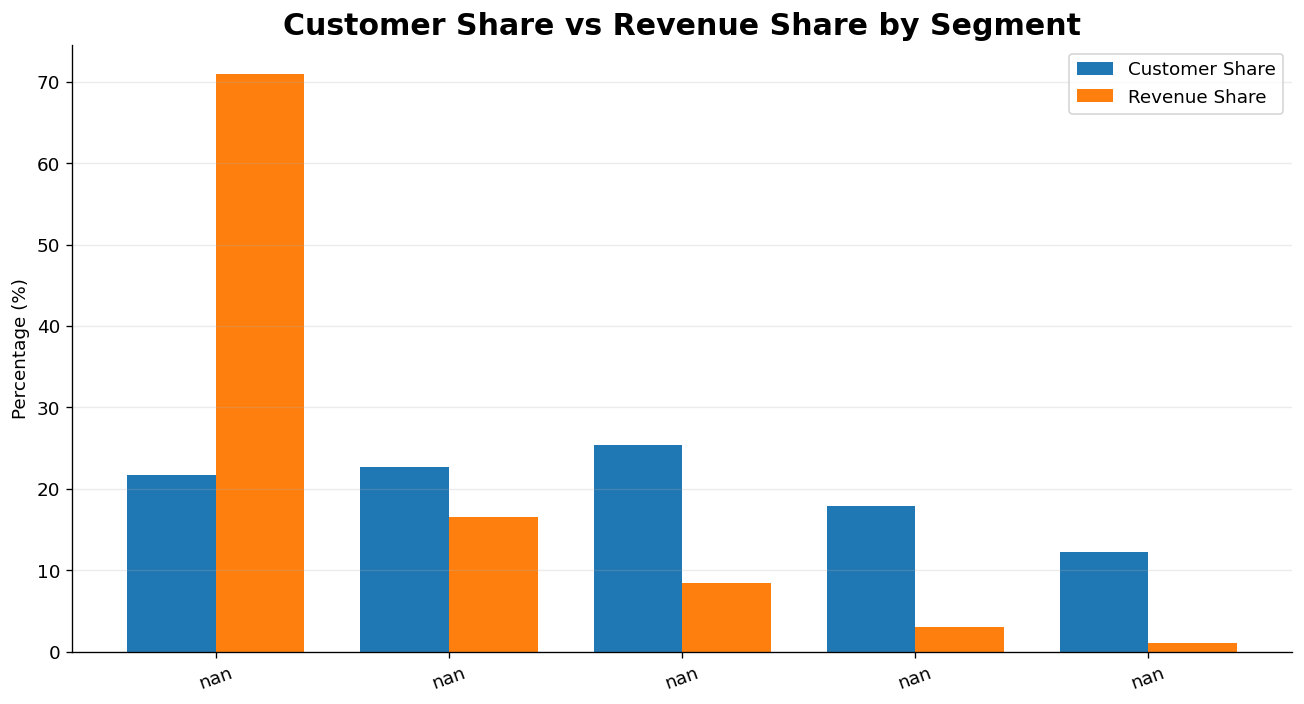

In [ ]:
plot_data = segment_summary.copy()

plt.figure(figsize=(11, 6))

x = np.arange(len(plot_data))
width = 0.38

plt.bar(
    x - width/2,
    plot_data["Customer_Share"],
    width,
    label="Customer Share"
)

plt.bar(
    x + width/2,
    plot_data["Revenue_Share"],
    width,
    label="Revenue Share"
)

plt.xticks(
    x,
    plot_data["Business_Segment"],
    rotation=20
)

plt.ylabel("Percentage (%)")
plt.title(
    "Customer Share vs Revenue Share by Segment",
    fontsize=18,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# Your segments are already labelled
segment_summary["Business_Segment"] = segment_summary["Segment"]

print(
    segment_summary[
        ["Segment", "Business_Segment"]
    ]
)

               Segment     Business_Segment
1            Champions            Champions
3      Loyal Customers      Loyal Customers
4  Potential Loyalists  Potential Loyalists
0              At Risk              At Risk
2       Lost Customers       Lost Customers


In [ ]:
print("========== KEY BUSINESS INSIGHTS ==========")

for _, row in segment_summary.iterrows():
    print(
        f"{row['Business_Segment']}: "
        f"{row['Customer_Share']:.2f}% of customers | "
        f"{row['Revenue_Share']:.2f}% of revenue"
    )

========== KEY BUSINESS INSIGHTS ==========
Champions: 21.69% of customers | 71.03% of revenue
Loyal Customers: 22.74% of customers | 16.56% of revenue
Potential Loyalists: 25.42% of customers | 8.39% of revenue
At Risk: 17.87% of customers | 2.97% of revenue
Lost Customers: 12.29% of customers | 1.05% of revenue


In [ ]:
top_segment = segment_summary.loc[
    segment_summary["Revenue_Share"].idxmax()
]

print("========== MOST VALUABLE SEGMENT ==========")

print(
    f"Segment: {top_segment['Business_Segment']}"
)

print(
    f"Customer Share: {top_segment['Customer_Share']:.2f}%"
)

print(
    f"Revenue Share: {top_segment['Revenue_Share']:.2f}%"
)

print(
    f"Total Revenue: £{top_segment['Total_Revenue']:,.2f}"
)

========== MOST VALUABLE SEGMENT ==========
Segment: Champions
Customer Share: 21.69%
Revenue Share: 71.03%
Total Revenue: £5,880,205.09


In [ ]:
risk_segment = segment_summary.loc[
    segment_summary["Customer_Share"].idxmax()
]

print("========== BIGGEST CUSTOMER SEGMENT ==========")

print(
    f"Segment: {risk_segment['Business_Segment']}"
)

print(
    f"Customer Share: {risk_segment['Customer_Share']:.2f}%"
)

print(
    f"Revenue Share: {risk_segment['Revenue_Share']:.2f}%"
)

========== BIGGEST CUSTOMER SEGMENT ==========
Segment: Potential Loyalists
Customer Share: 25.42%
Revenue Share: 8.39%


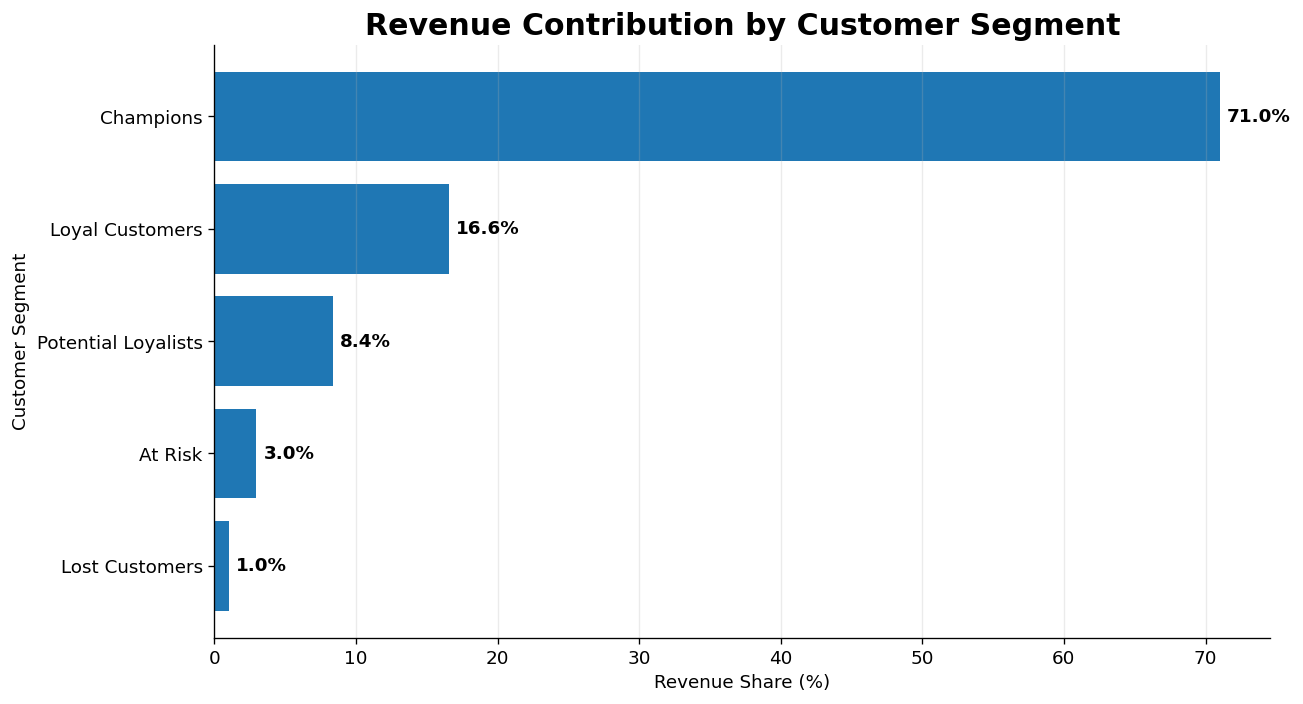

In [ ]:
import matplotlib.pyplot as plt

plot_data = segment_summary.sort_values(
    "Revenue_Share",
    ascending=True
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    plot_data["Business_Segment"],
    plot_data["Revenue_Share"]
)

plt.title(
    "Revenue Contribution by Customer Segment",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Revenue Share (%)")
plt.ylabel("Customer Segment")

# Add percentage labels
for bar, value in zip(bars, plot_data["Revenue_Share"]):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center",
        fontweight="bold"
    )

plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# Create final customer-level dataset

customer_final = rfm.copy()

# Keep the important customer segmentation columns
customer_final = customer_final[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "Segment"
    ]
].copy()

customer_final.head()

,CustomerID,Recency,Frequency,Monetary,Segment
0,12346.0,325,2,0.00,Lost Customers
1,12347.0,2,7,4310.00,Champions
2,12348.0,75,4,1797.24,Potential Loyalists
3,12349.0,18,1,1757.55,Potential Loyalists
4,12350.0,310,1,334.40,Lost Customers


In [ ]:
print("Customers:", len(customer_final))
print("Columns:", customer_final.columns.tolist())

Customers: 4371
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment']


In [ ]:
# Create final customer-level dataset

customer_final = rfm.copy()

# Keep the important customer segmentation columns
customer_final = customer_final[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "Segment"
    ]
].copy()

customer_final.head()

,CustomerID,Recency,Frequency,Monetary,Segment
0,12346.0,325,2,0.00,Lost Customers
1,12347.0,2,7,4310.00,Champions
2,12348.0,75,4,1797.24,Potential Loyalists
3,12349.0,18,1,1757.55,Potential Loyalists
4,12350.0,310,1,334.40,Lost Customers




```
# This is formatted as code
```



In [ ]:
# Create final customer-level dataset

customer_final = rfm.copy()

customer_final = customer_final[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "Segment"
    ]
].copy()

print("Customers:", len(customer_final))
print("Columns:", customer_final.columns.tolist())

customer_final.head()

Customers: 4371
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment']


,CustomerID,Recency,Frequency,Monetary,Segment
0,12346.0,325,2,0.00,Lost Customers
1,12347.0,2,7,4310.00,Champions
2,12348.0,75,4,1797.24,Potential Loyalists
3,12349.0,18,1,1757.55,Potential Loyalists
4,12350.0,310,1,334.40,Lost Customers


In [ ]:
# Create final customer-level dataset

customer_final = rfm.copy()

customer_final = customer_final[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "Segment"
    ]
].copy()

print("Customers:", len(customer_final))
print("Columns:", customer_final.columns.tolist())

customer_final.head()

Customers: 4371
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment']


,CustomerID,Recency,Frequency,Monetary,Segment
0,12346.0,325,2,0.00,Lost Customers
1,12347.0,2,7,4310.00,Champions
2,12348.0,75,4,1797.24,Potential Loyalists
3,12349.0,18,1,1757.55,Potential Loyalists
4,12350.0,310,1,334.40,Lost Customers


In [ ]:
customer_country = (
    df_clean
    .groupby("CustomerID")["Country"]
    .agg(lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0])
    .reset_index()
)

customer_final = customer_final.merge(
    customer_country,
    on="CustomerID",
    how="left"
)

print(customer_final.columns.tolist())

['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment', 'Country']


In [ ]:
customer_final["Revenue_Share"] = (
    customer_final["Monetary"] /
    customer_final["Monetary"].sum()
)

customer_final.head()

,CustomerID,Recency,Frequency,Monetary,Segment,Country,Revenue_Share
0,12346.0,325,2,0.00,Lost Customers,United Kingdom,0.000000
1,12347.0,2,7,4310.00,Champions,Iceland,0.000521
2,12348.0,75,4,1797.24,Potential Loyalists,Finland,0.000217
3,12349.0,18,1,1757.55,Potential Loyalists,Italy,0.000212
4,12350.0,310,1,334.40,Lost Customers,Norway,0.000040


In [ ]:
customer_final.to_csv(
    "customer_segmentation_final.csv",
    index=False
)

print("Customer segmentation file created successfully!")

Customer segmentation file created successfully!


In [ ]:
df_clean.to_csv(
    "online_retail_cleaned.csv",
    index=False
)

print("Clean transaction dataset created successfully!")

Clean transaction dataset created successfully!


In [ ]:
import os

print(os.listdir())

['.config', 'online_retail_cleaned.csv', 'drive', 'Online Retail.xlsx', 'customer_segmentation_final.csv', 'sample_data']


In [ ]:
from google.colab import files

files.download("online_retail_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("customer_segmentation_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Merge customer segmentation information into transaction data

dashboard_df = df_clean.merge(
    rfm[
        [
            "CustomerID",
            "Recency",
            "Frequency",
            "Monetary",
            "Segment"
        ]
    ],
    on="CustomerID",
    how="left"
)

print("Rows:", len(dashboard_df))
print("Columns:", dashboard_df.columns.tolist())

NameError: name 'df_clean' is not defined